# Đọc dữ liệu 

In [133]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


In [134]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

print(train.shape)
print(test.shape)
train.head()

(8693, 14)
(4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00,False,0.00,0.00,0.00,0.00,0.00,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00,False,109.00,9.00,25.00,549.00,44.00,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00,True,43.00,"3,576.00",0.00,"6,715.00",49.00,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.00,False,0.00,"1,283.00",371.00,"3,329.00",193.00,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.00,False,303.00,70.00,151.00,565.00,2.00,Willy Santantines,True


In [135]:
X_raw = train.drop(columns=["Transported"])  
y = train["Transported"]
missing = X_raw.isnull().sum()
# duplicate = X_raw.duplicated().sum()            

In [136]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
print(X_raw.describe().T)
print("\nMissing columns:")
print(missing)
print("\nDuplicated columns: ", X_raw.duplicated().sum())


                count   mean      std  min   25%   50%   75%       max
Age          8,514.00  28.83    14.49 0.00 19.00 27.00 38.00     79.00
RoomService  8,512.00 224.69   666.72 0.00  0.00  0.00 47.00 14,327.00
FoodCourt    8,510.00 458.08 1,611.49 0.00  0.00  0.00 76.00 29,813.00
ShoppingMall 8,485.00 173.73   604.70 0.00  0.00  0.00 27.00 23,492.00
Spa          8,510.00 311.14 1,136.71 0.00  0.00  0.00 59.00 22,408.00
VRDeck       8,505.00 304.85 1,145.72 0.00  0.00  0.00 46.00 24,133.00

Missing columns:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64

Duplicated columns:  0


In [137]:
X_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
dtypes: float64(6), object(7)
memory usage: 883.0+ KB


- Một dòng dữ liệu đại diện cho một vị khách du hành và 13 cột đại diện cho những đặc trưng của vị khách đó. Trong đó có 6 cột numeric và 7 cột alpha 

- Có 12 cột bị thiếu, 0 có cột bị trùng lặp.

- Transport nên được dùng cho giai đoạn Evaluation. Vì đây là nhãn đã biết trước và là target của model, model sẽ tự tin (Overfitting)

# EDA + Feature Engineering 


## Numeric-columns 

In [138]:
import pandas as pd

numeric_cols = train.select_dtypes(include="number").columns

missing_numeric = pd.DataFrame({
    "Missing": train[numeric_cols].isna().sum(),
    "Missing (%)": train[numeric_cols].isna().mean() * 100
}).sort_values("Missing (%)", ascending=False)

print(missing_numeric)

              Missing  Missing (%)
ShoppingMall      208         2.39
VRDeck            188         2.16
FoodCourt         183         2.11
Spa               183         2.11
RoomService       181         2.08
Age               179         2.06


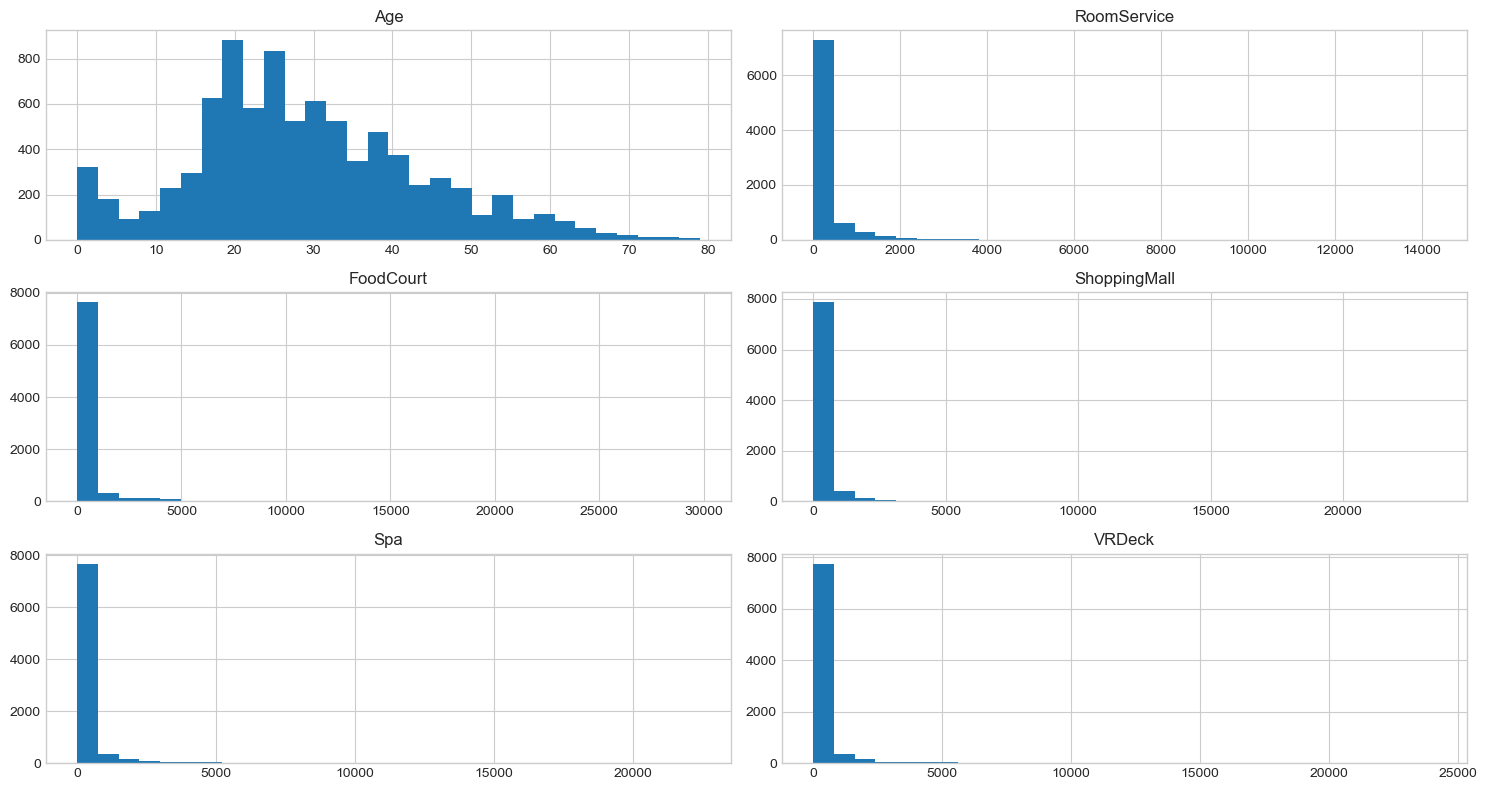

In [139]:
numeric_cols = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

train[numeric_cols].hist(figsize=(15, 8), bins=30)
plt.tight_layout()
plt.show()

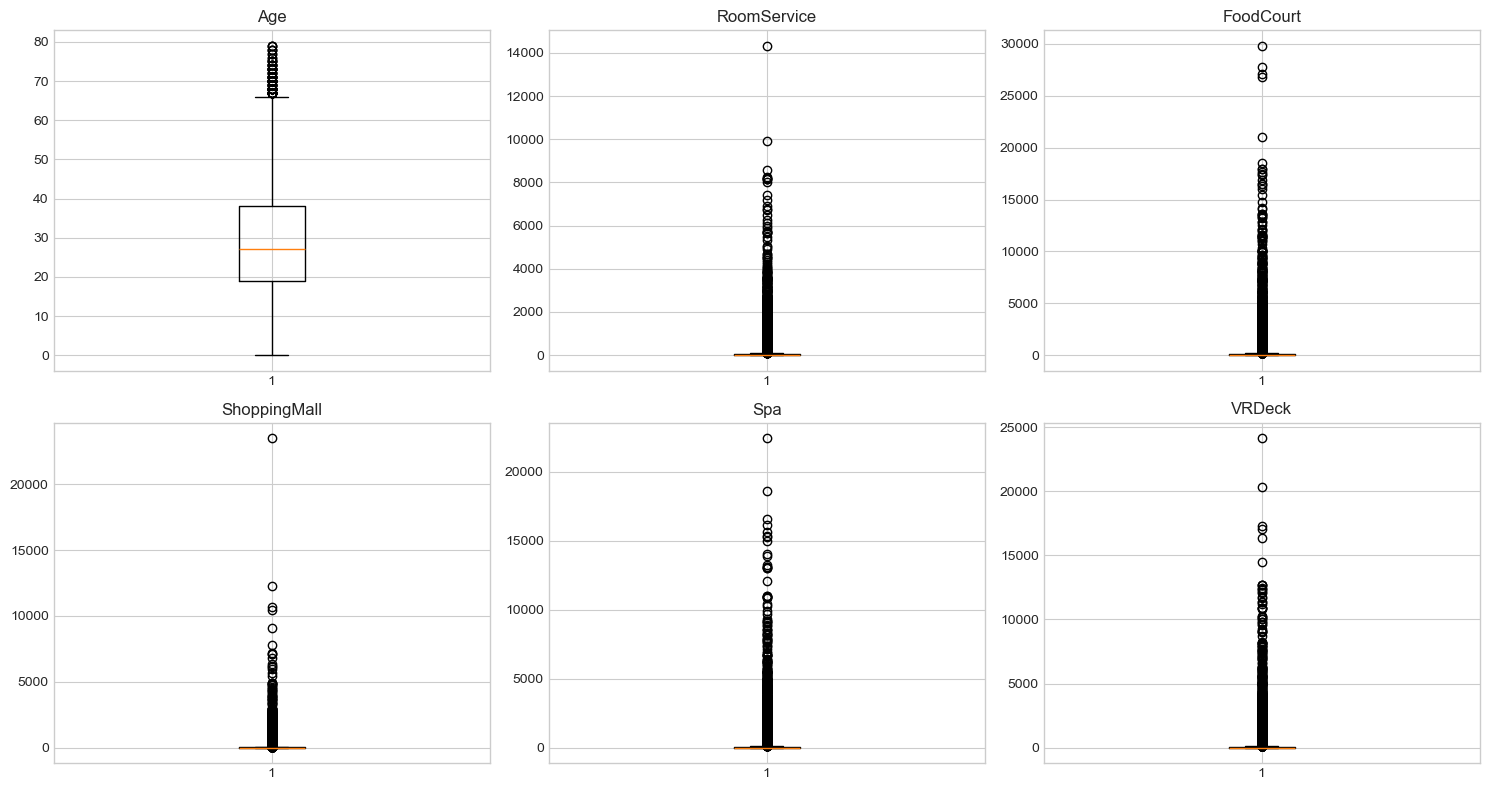

In [140]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), numeric_cols):
    ax.boxplot(train[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

- Đối với Age : Có nhiều outliers -> điền median cho giá trị còn thiếu

- Đối với 5 cột chi tiêu còn lại : Có nhiều outlier, phân phối xuất hiện nhiều số 0 -> ta fill các giá trị còn thiếu với median để tránh lệch dữ liệu 

In [141]:
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]


## Alpha-columns

In [142]:
alpha_cols = X_raw.select_dtypes(include="object").columns.tolist()
print(alpha_cols)

['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


In [143]:
missing_alpha = pd.DataFrame({
    "Missing": X_raw[alpha_cols].isna().sum(),
    "Missing (%)": X_raw[alpha_cols].isna().mean() * 100
}).sort_values("Missing (%)", ascending=False)

print(missing_alpha)

             Missing  Missing (%)
CryoSleep        217         2.50
VIP              203         2.34
HomePlanet       201         2.31
Name             200         2.30
Cabin            199         2.29
Destination      182         2.09
PassengerId        0         0.00


### CryoSleep

In [144]:
print(X_raw["CryoSleep"].value_counts(dropna=False))

CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64


In [145]:
X_raw[X_raw["CryoSleep"].isna()].head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
92,0099_02,Earth,NaN,G/12/P,TRAPPIST-1e,2.00,False,0.00,0.00,0.00,0.00,0.00,Thewis Connelson
98,0105_01,Earth,NaN,F/21/P,TRAPPIST-1e,27.00,False,0.00,0.00,570.00,2.00,131.00,Carry Cleachrand
104,0110_02,Europa,NaN,B/5/P,TRAPPIST-1e,40.00,False,0.00,331.00,0.00,0.00,"1,687.00",Aldeba Bootious
111,0115_01,Mars,NaN,F/24/P,TRAPPIST-1e,26.00,False,0.00,0.00,0.00,0.00,NaN,Rohs Pead
152,0173_01,Earth,NaN,E/11/S,TRAPPIST-1e,58.00,False,0.00,985.00,0.00,5.00,0.00,Hilip Grifford


In [146]:
X_raw["TotalSpend"] = X_raw[spending_cols].sum(axis=1)
test["TotalSpend"] = test[spending_cols].sum(axis = 1)

pd.crosstab(
    X_raw["CryoSleep"],
    X_raw["TotalSpend"] > 0,
    normalize="index"
)

TotalSpend,False,True
CryoSleep,,
False,0.10,0.90
True,1.00,0.00


- Vì có 100% hành khách chọn CryoSleep có TotalSpend = 0, ta sẽ fill True cho CryoSleep vào những vị trí có TotalSpend = 0

- Ngược lại, có 90% hành khách không chọn CryoSleep, có TotalSpend > 0, ta sẽ fill mode cho những vị trí có TotalSpend > 0

In [147]:
mask = X_raw["CryoSleep"].isna() & (X_raw["TotalSpend"] > 0)
X_raw.loc[mask,"CryoSleep"] = False

mask = test["CryoSleep"].isna() & (test["TotalSpend"] > 0)
test.loc[mask, "CryoSleep"] = False


### VIP

In [148]:
X_raw["VIP"].value_counts(dropna=False)

VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64

Vì số liệu mất cân bằng, False chiếm đa số, ta fill mode cho VIP

### HomePlanet

In [149]:
X_raw["HomePlanet"].value_counts(dropna=False)

HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64

- Missing ít, Earth đang chiếm đa số, ta điền mode cho HomePlanet

### Destination

In [150]:
X_raw["Destination"].value_counts(dropna=False)

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64

- Missing ít, TRAPPIST-1e đang chiếm đa số, ta điền mode cho Destination

### Name

In [151]:
X_raw["Name"].value_counts(dropna=False)

Name
NaN                   200
Sus Coolez              2
Elaney Webstephrey      2
Dia Cartez              2
Grake Porki             2
                     ... 
Jamela Griffy           1
Hardy Griffy            1
Salley Mckinn           1
Mall Frasp              1
Propsh Hontichre        1
Name: count, Length: 8474, dtype: int64

- Cột Name chứa tên của hành khách và có missing ít. 
- Do tên là thông tin của cá nhân, rất khó suy luận hoặc khôi phục dựa trên các đặc trưng còn lại. 
- Đồng thời, tên cũng không mang ý nghĩa để dự đoán hành khách đã Transported hay chưa, khác so với các cột còn lại có thể mang ý nghĩa nhất định đối với Transport. 

- Vì vậy, lựa chọn drop cột Name khỏi tập dữ liệu thay vì điền các giá trị thiếu là hợp lí hơn

In [152]:
X_raw = X_raw.drop(columns=["Name"])
test = test.drop(columns=["Name"])

### Cabin

In [153]:
X_raw["Cabin"].value_counts(dropna=False)

Cabin
NaN        199
G/734/S      8
C/137/S      7
B/201/P      7
G/109/P      7
          ... 
G/556/P      1
E/231/S      1
G/545/S      1
G/543/S      1
C/178/S      1
Name: count, Length: 6561, dtype: int64

Cabin mang cấu trúc deck/num/side, nên feature engineering cái này trước

In [154]:
X_raw[["Deck", "CabinNum", "Side"]] = X_raw["Cabin"].str.split("/", expand=True)
test[["Deck", "CabinNum", "Side"]] = test["Cabin"].str.split("/", expand=True)

X_raw["CabinNum"] = pd.to_numeric(X_raw["CabinNum"], errors="coerce")
test["CabinNum"] = pd.to_numeric(test["CabinNum"], errors="coerce")

print(X_raw[["Deck","CabinNum","Side"]].isna().sum())

Deck        199
CabinNum    199
Side        199
dtype: int64


#### Deck


In [155]:
X_raw["Deck"].value_counts(dropna=False)

Deck
F      2794
G      2559
E       876
B       779
C       747
D       478
A       256
NaN     199
T         5
Name: count, dtype: int64

- Missing ít, Deck F đang chiếm đa số, ta điền mode cho cột Deck bị thiếu

#### CabinNum

In [156]:
X_raw["CabinNum"].describe()

count   8,494.00
mean      600.37
std       511.87
min         0.00
25%       167.25
50%       427.00
75%       999.00
max     1,894.00
Name: CabinNum, dtype: float64

In [157]:
X_raw["CabinNum"].value_counts(dropna=False)

CabinNum
NaN         199
82.00        28
86.00        22
19.00        22
56.00        21
           ... 
1,644.00      1
1,515.00      1
1,639.00      1
1,277.00      1
1,894.00      1
Name: count, Length: 1818, dtype: int64

- CabinNum nên điền median, vì outliers kéo mean lệch khá lớn.

#### Side 

In [158]:
X_raw["Side"].value_counts(dropna=False)

Side
S      4288
P      4206
NaN     199
Name: count, dtype: int64

Dữ liệu cân bằng, ta sẽ điền mode cho NaN của Side.

In [159]:
X_raw = X_raw.drop(columns=["Cabin"])
test = test.drop(columns=["Cabin"])

### PassengerId

- Tuy không có missing value, song dữ liệu này có định dạng đặc biệt `gggg_pp` (gggg : mã nhóm, pp: mã số người đó trong nhóm) nên ta có thể feature engineering ra một cột là GroupID.

- Khi có cột GroupID, ta tiếp tục feature engineer để thu được size của GroupID đó

In [160]:
X_raw["GroupID"] = X_raw["PassengerId"].str.split("_").str[0]
test["GroupID"] = test["PassengerId"].str.split("_").str[0]

group_size = X_raw.groupby("GroupID").size()
X_raw["GroupSize"] = X_raw["GroupID"].map(group_size)

group_size_test = test.groupby("GroupID").size()
test["GroupSize"] = test["GroupID"].map(group_size_test)

Sau khi thu được GroupSize, ta có thể drop GroupID và PassengerId

In [161]:
X_raw = X_raw.drop(columns=["GroupID"])
test = test.drop(columns=["GroupID"])
test_id = test["PassengerId"]
X_raw = X_raw.drop(columns=["PassengerId"])
test = test.drop(columns=["PassengerId"])

# Model Selection

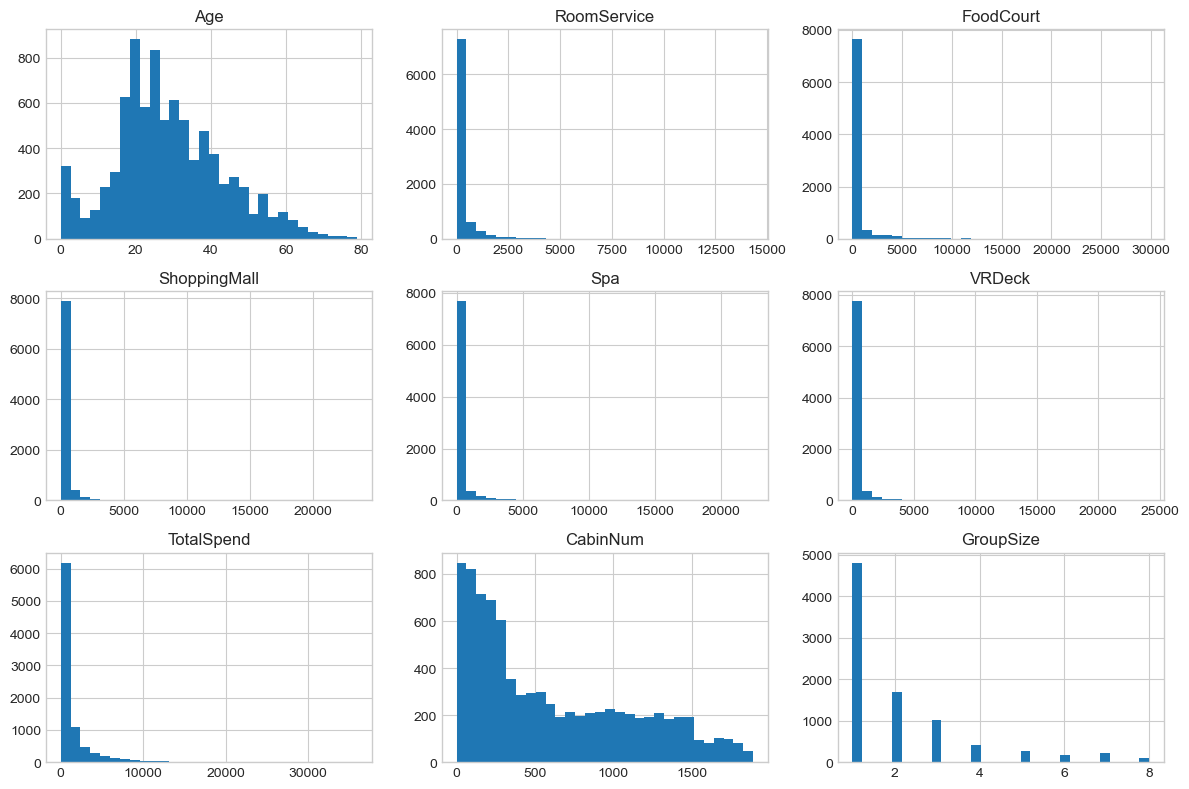

In [162]:
X_raw.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

Nhận xét:

- Tất cả các nhóm đều có phân phối lệch phải (right-skewed)

> Có thể dùng log1p transform để nén dữ liệu và đa số các dữ liệu có khoảng cách rất xa nhau


Xử lý sự mất cân bằng về khoảng cách giữa cách điểm trong TotalSpend

In [166]:
X_raw["TotalSpend"] = np.log1p(X_raw["TotalSpend"])

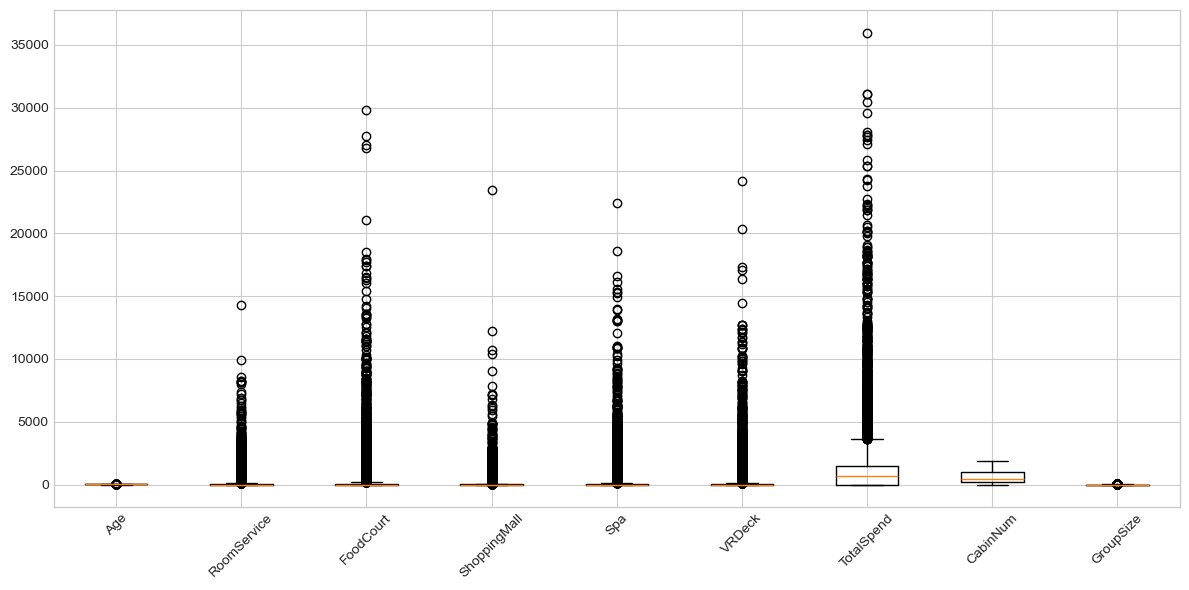

In [163]:
numeric_cols = X_raw.select_dtypes(include="number").columns

plt.figure(figsize=(12, 6))

plt.boxplot(
    [X_raw[col].dropna() for col in numeric_cols],
    tick_labels=numeric_cols
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Tuy lệch phải, đồ thị cho một xu hướng outliers rất lớn

> Đây không phải noise mà phản ánh có rất nhiều khách hàng đặc biệt, nên giữ lại các outliers này.


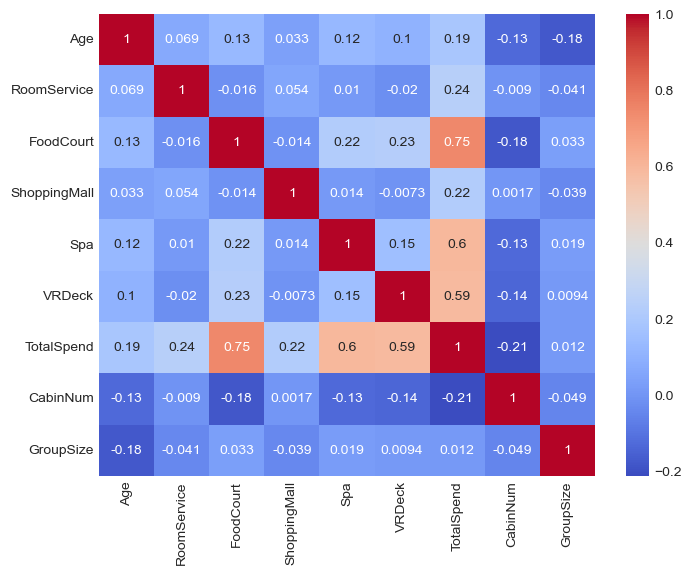

In [164]:
import seaborn as sns

corr = X_raw.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

- Có `FoodCourt` và `TotalSpend` có sự tương quan khá mạnh(0.74)

> Có thể cân nhắc loại bỏ một trong hai features để giảm chiều dữ liệu (PCA)

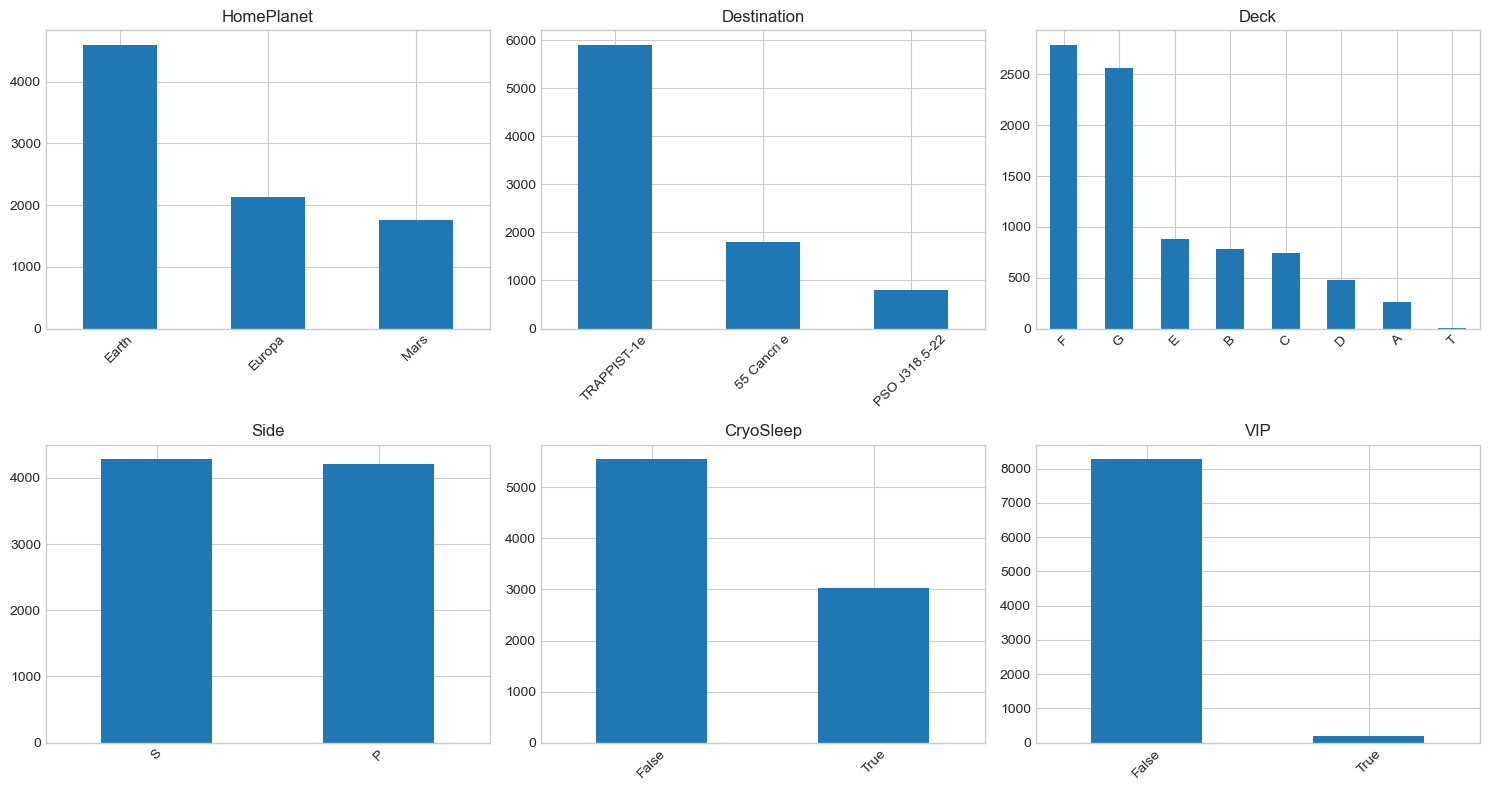

In [165]:
categorical_cols = [
    "HomePlanet",
    "Destination",
    "Deck",
    "Side",
    "CryoSleep",
    "VIP"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    X_raw[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

- Earth là hành tinh xuất phát phổ biến nhất trong HomePlanet.

- Đa số hành khách có điểm đến là TRAPPIST-1e, dữ liệu cho Destination có sự mất cân bằng khi 1 destination chiếm quá ưu thế 

- Deck F và G có sự ưu thế về số hành khách hơn các Deck còn lại

- Hai side P và S tương đương, dữ liệu cân bằng tốt.

- Số hành khách không chọn CryoSleep đang cao hơn gấp đôi so với phe đối diện, nhìn chung không quá mất cân bằng 

- Số hành khách VIP chiếm thiểu số, dữ liệu mất cân bằng lớn

> Với những dữ liệu mất cân bằng lớn, sẽ khó để ML học được thông tin quan trọng 

>Đề xuất xử lý những giá trị categorical ra thông tin để máy có thể học 

>- Các cột bool lần lượt là : VIP, CryoSleep, ta chuyển bool sang int [0,1]

>- Các cột phân loại lần lượt là : HomePlanet, Destination, Deck,Side, ta chuyển các categorical này sang one-hot encoding 

# Preprocessing 

In [167]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])



In [168]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_cols
        ),
        (
            "cat",
            categorical_transformer,
            categorical_cols
        )
    ]
)

# Cross Validation

Cross-Validation là lựa chọn thích hợp cho bài toán này, để tránh việc dựa vào phép chia, mà thử trên nhiều phép chia K-Fold

In [169]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ensemble Learning

## Boosting (XGBoost)

In [170]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

pipeline_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=42))
])

Việc chỉnh tham số thủ công rất dễ gây underfit cho model, model cần phải tìm ra siêu tham số thích hợp cho bài toán 

In [171]:
from scipy.stats import randint, uniform
xgb_param_dist = {
    "classifier__n_estimators": randint(200, 600),
    "classifier__max_depth": randint(3, 8),
    "classifier__learning_rate": uniform(0.03, 0.15),
    "classifier__subsample": uniform(0.6, 0.4),
    "classifier__colsample_bytree": uniform(0.6, 0.4),
    "classifier__min_child_weight": randint(1, 8),
    "classifier__gamma": [0, 0.1, 0.3],
    "classifier__reg_lambda": [1, 2, 5]
}

search = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
)

search.fit(X_raw, y)


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'classifier__colsample_bytree': <scipy.stats....t 0x30d088350>, 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': <scipy.stats....t 0x165226ad0>, 'classifier__max_depth': <scipy.stats....t 0x30d0611d0>, ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [172]:
print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)

best_xgb = search.best_estimator_

Best params: {'classifier__colsample_bytree': np.float64(0.6092249700165663), 'classifier__gamma': 0.3, 'classifier__learning_rate': np.float64(0.12177793420835692), 'classifier__max_depth': 4, 'classifier__min_child_weight': 4, 'classifier__n_estimators': 387, 'classifier__reg_lambda': 5, 'classifier__subsample': np.float64(0.7824279936868144)}
Best CV accuracy: 0.8127233420527252


## Bagging (Random Forest)

In [173]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    
    ("classifier", RandomForestClassifier(random_state=42))
    
])
rf_param_dist = {
    "classifier__n_estimators": randint(200,600),
    "classifier__max_depth":[None,10,15,20,30],
    "classifier__min_samples_split": randint(2,10),
    "classifier__min_samples_leaf": randint(1,5),
    "classifier__max_features":["sqrt","log2"],
    "classifier__bootstrap":[True,False]
}

rf_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_raw, y)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'classifier__bootstrap': [True, False], 'classifier__max_depth': [None, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': <scipy.stats....t 0x30b38ec50>, ...}"
,n_iter,50
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [174]:
print("Best Score:", rf_search.best_score_)
print("Best Params:")
print(rf_search.best_params_)

best_rf = rf_search.best_estimator_


Best Score: 0.8078910607593613
Best Params:
{'classifier__bootstrap': True, 'classifier__max_depth': 15, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 3, 'classifier__n_estimators': 369}


## Ensemble Stacking

In [175]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# base model
estimators = [
    ("rf", best_rf),
    ("xgb", best_xgb)
]

#meta model

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)

stack.fit(X_raw, y)

,estimators,"[('rf', ...), ('xgb', ...)]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


## Ensemble Voting

In [176]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(
    estimators=estimators,
    voting="soft"
)
voting.fit(X_raw, y)

,estimators,"[('rf', ...), ('xgb', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [177]:
from sklearn.model_selection import cross_val_score

results = {
    "Random Forest": rf_search.best_score_,
    "Extreme Gradient Boosting": search.best_score_,
    "Voting": cross_val_score(voting, X_raw, y, cv=cv).mean(),
    "Stacking": cross_val_score(stack, X_raw, y, cv=cv).mean(),
}

print("Benchmark result:\n")

for model, score in results.items():
    print(model)
    print(f"Accuracy: {score:.4f}")
    print("-" * 30)

Benchmark result:

Random Forest
Accuracy: 0.8079
------------------------------
Extreme Gradient Boosting
Accuracy: 0.8127
------------------------------
Voting
Accuracy: 0.8097
------------------------------
Stacking
Accuracy: 0.8112
------------------------------


- Bốn kĩ thuật ensemble đều đạt kết quả Accuracy trên 81%, trong đó kết quả tốt nhất là XGBoosting(81.27%), hơn kết quả của Stacking (81,12%) khi kết hợp RandomForest(80,79%) và XGBoosting(81,27%) làm base data để dùng Logistic Regression train ra meta model cuối cùng

- Việc kết hợp cả hai ưu điểm của bagging và boosting giúp accuracy cho model tăng.

- Tuy rằng model XGB tốt, ta sẽ chọn model Stacking làm final model, bởi vì việc kết hợp hai thuật toán vẫn nên được ưu tiên, và Accuracy của XGB và Stacking tương đối ngang nhau, ta sẽ lựa chọn thuật toán có độ phức tạp lớn hơn khi gặp tập test 

# Evaluation

In [178]:
stack.fit(X_raw, y)

,estimators,"[('rf', ...), ('xgb', ...)]"
,final_estimator,LogisticRegre...max_iter=1000)
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


In [179]:
prediction = stack.predict(test)

In [180]:
submission = pd.DataFrame({
    "PassengerId": test_id,
    "Transported": prediction
})
submission["Transported"] = submission["Transported"].astype(bool)
submission.to_csv("submission.csv", index=False)

In [181]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  4277 non-null   object
 1   Transported  4277 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 37.7+ KB


# Báo cáo kết quả 

- Mô hình đạt điểm số 0.80500 trên bảng xếp hạng Kaggle.

- Kết quả đạt được nhờ quá trình khám phá dữ liệu (EDA), tiền xử lý dữ liệu (Data Preprocessing) và Feature Engineering, giúp cải thiện chất lượng dữ liệu đầu vào và xây dựng các đặc trưng phù hợp cho mô hình học máy.

- Mô hình sử dụng Stacking Ensemble, kết hợp Random Forest (Bagging) và XGBoost (Boosting) nhằm tận dụng ưu điểm của các thuật toán có cơ chế học khác nhau, từ đó cải thiện khả năng dự đoán.

- Accuracy của mô hình vẫn có thể được nâng cao bằng cách tiếp tục Feature Engineering, Data Cleaning, tối ưu siêu tham số (Hyperparameter Tuning) cho các mô hình thành phần và thử nghiệm thêm các mô hình khác trong Stacking Ensemble.
